In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import os
import sys

# -----------------------------------------------------------------------------
# Data file
# -----------------------------------------------------------------------------
# The workbook name and location are fixed.
root_dir = os.path.abspath("../..")
sys.path.append(root_dir)


CASE_ID = "C0003"
CASE_NAME = "C0003R02_PARK25_LC_1D_SCAN"

data_file = os.path.join(root_dir, "data", CASE_ID, f'{CASE_NAME}.xlsx')
sheet_name = 'Parameter scan'

data = pd.read_excel(data_file, sheet_name=sheet_name)

print(f'Data file: {data_file}')
print(f'Number of scan cases: {len(data)}')
data.head() # display the first five rows as a demo

Data file: d:\Workspace\eBATS\data\C0003\C0003R02_PARK25_LC_1D_SCAN.xlsx
Number of scan cases: 144


,case_id,T_water_in_C,m_dot_total_kg_s,num_cell_seg,num_parallel_channels,m_dot_channel_kg_s,Dh_mm,u_water_m_s,Re_water,P_pump,...,DeltaT_mission_max_C,Twater_out_cruise_end_C,dTmax_takeoff_C,dTmax_climb_C,dTmax_transition1_C,dTmax_cruise_C,dTmax_transition2_C,dTmax_descent_C,dTmax_hover_C,dTmax_landing_C
0,C0003_S001,20,0.045,1.333333,12,0.003750,4.363636,0.156531,680.731637,0.013402,...,1.085045,20.475053,0.415090,1.475418,1.115929,-0.479069,-0.755113,0.508139,12.459443,0.376525
1,C0003_S002,20,0.045,1.000000,16,0.002812,4.363636,0.117398,510.548728,0.010052,...,1.423821,20.469645,0.414166,1.453403,0.932040,-0.808965,-0.714706,0.515965,11.829531,0.339079
2,C0003_S003,20,0.045,0.800000,20,0.002250,4.363636,0.093918,408.438982,0.008041,...,1.775868,20.465828,0.413397,1.435172,0.786187,-0.964211,-0.682568,0.521732,11.317774,0.309541
3,C0003_S004,20,0.045,0.666667,24,0.001875,4.363636,0.078265,340.365818,0.006701,...,2.124363,20.463283,0.412765,1.420130,0.667734,-1.041080,-0.657209,0.526117,10.895990,0.285642
4,C0003_S005,20,0.045,0.571429,28,0.001607,4.363636,0.067085,291.742130,0.005744,...,2.458603,20.461535,0.412251,1.407779,0.569360,-1.079064,-0.636819,0.529654,10.543664,0.265857


In [2]:
# Select the columns required for the thermal-performance analysis.
plot_data = data[
    [
        'm_dot_total_kg_s',
        'T_water_in_C',
        'Dh_mm',
        'num_parallel_channels',
        'Tmax_mission_C',
        'DeltaT_mission_max_C',
        'P_pump',
        'm_plate_kg',
        'm_coolant_kg',
        'mtotal',
    ]
].copy()

# Convert the plotting columns to numeric values.
for column in plot_data.columns:
    plot_data[column] = pd.to_numeric(plot_data[column], errors='raise')

plot_data.head()


,m_dot_total_kg_s,T_water_in_C,Dh_mm,num_parallel_channels,Tmax_mission_C,DeltaT_mission_max_C,P_pump,m_plate_kg,m_coolant_kg,mtotal
0,0.045,20,4.363636,12,35.116362,1.085045,0.013402,1.391799,0.109244,1.501043
1,0.045,20,4.363636,16,33.960513,1.423821,0.010052,1.825131,0.145658,1.970790
2,0.045,20,4.363636,20,33.137023,1.775868,0.008041,2.258464,0.182073,2.440537
3,0.045,20,4.363636,24,32.510089,2.124363,0.006701,2.691796,0.218488,2.910284
4,0.045,20,4.363636,28,32.012681,2.458603,0.005744,3.125129,0.254902,3.380031


Processing mdotc = 0.045
Intersection x: 27.04204204204204 for Mdot_cin = 0.045 and N_ch = 20
Processing mdotc = 0.05
Intersection x: 27.04204204204204 for Mdot_cin = 0.05 and N_ch = 20
Processing mdotc = 0.055
Intersection x: 27.04204204204204 for Mdot_cin = 0.055 and N_ch = 20
Processing mdotc = 0.06
Intersection x: 27.04204204204204 for Mdot_cin = 0.06 and N_ch = 20
Processing mdotc = 0.065
Intersection x: 27.04204204204204 for Mdot_cin = 0.065 and N_ch = 20
Processing mdotc = 0.07
Intersection x: 27.04204204204204 for Mdot_cin = 0.07 and N_ch = 20


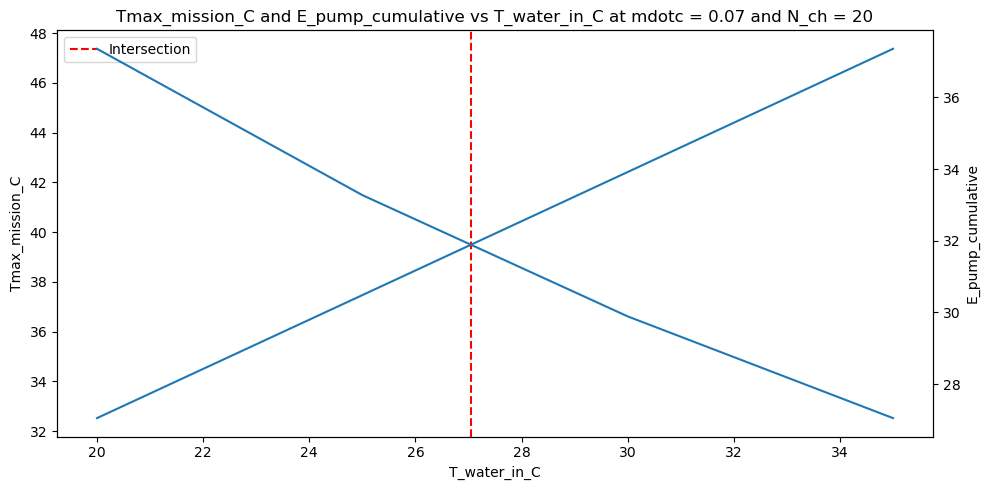

In [3]:
# plot Temperature max, cumulative Pump Energy at a given mdot and N_ch 
import lib.plot_util as plot_util

# extract all mdotc values into a list
mdotc_all = data['m_dot_total_kg_s'].unique()
intersection_T_all = [] 
x_name = 'T_water_in_C'
y1_name = 'Tmax_mission_C'
y2_name = 'DeltaT_mission_max_C'
y3_name = 'E_pump_cumulative'

for mdotc in mdotc_all:
    print(f'Processing mdotc = {mdotc}')
    N_ch = 20
    # Filter the data for the given mdot and N_ch values
    filtered_data = data[(data['m_dot_total_kg_s'] == mdotc) & (data['num_parallel_channels'] == N_ch)]

    intersection_x = plot_util.find_curve_intersection(filtered_data[x_name], filtered_data[y1_name], filtered_data[y3_name])
    intersection_T_all.append(intersection_x)
    
    print(f'Intersection x: {intersection_x} for Mdot_cin = {mdotc} and N_ch = {N_ch}')

# Plot Temperature max
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()

# plt.subplot(1, 2, 1)
ax1.plot(filtered_data[x_name], filtered_data[y1_name])

if intersection_x is not None:
    ax1.axvline(intersection_x, color='red', linestyle='--', label='Intersection')
    ax1.legend()
    
ax1.set_xlabel(x_name)
ax1.set_ylabel(y1_name)
ax1.set_title(f'{y1_name} and {y3_name} vs {x_name} at mdotc = {mdotc} and N_ch = {N_ch}')

# Plot cumulative Pump Energy
# plt.subplot(1, 2, 2)
ax2 = plt.twinx()
ax2.plot(filtered_data[x_name], filtered_data[y3_name])
ax2.set_xlabel(x_name)
ax2.set_ylabel(y3_name)
# ax2.set_title(f'{y3_name} vs {x_name}')

plt.tight_layout()
plt.show()

Intersection x: 0.05693693693693694 for T_cold_in = 20 and N_ch = 20
Intersection x: 0.05693693693693694 for T_cold_in = 25 and N_ch = 20
Intersection x: 0.05693693693693694 for T_cold_in = 30 and N_ch = 20
Intersection x: 0.05693693693693694 for T_cold_in = 35 and N_ch = 20


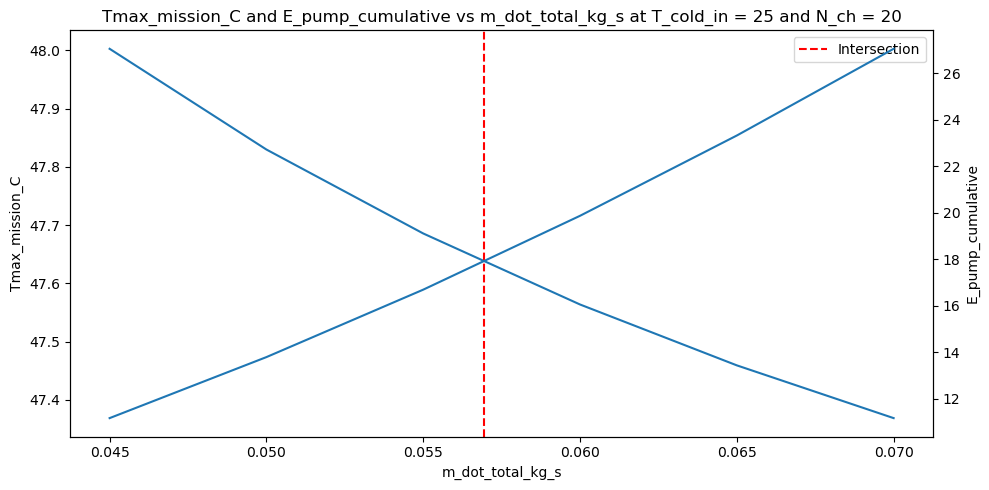

In [4]:
# plot the Tbmax and Epump at a fixed T cold cin and N_ch

N_ch = 20
T_cold_in_all = data['T_water_in_C'].unique()

T_cold_in = 25  # fixed T cold cin value

filtered_data = data[(data['num_parallel_channels'] == N_ch) & (data['T_water_in_C'] == T_cold_in)]

x_name = 'm_dot_total_kg_s'
y1_name = 'Tmax_mission_C'
y2_name = 'DeltaT_mission_max_C'
y3_name = 'E_pump_cumulative'

intersection_mdotc_all = []

for Tcin in T_cold_in_all:
    filtered_data = data[(data['num_parallel_channels'] == N_ch) & (data['T_water_in_C'] == Tcin)]

    intersection_x = plot_util.find_curve_intersection(filtered_data[x_name], filtered_data[y1_name], filtered_data[y3_name])
    intersection_mdotc_all.append(intersection_x)

    print(f'Intersection x: {intersection_x} for T_cold_in = {Tcin} and N_ch = {N_ch}')

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()

# Plot Tmax_mission_C
ax1.plot(filtered_data[x_name], filtered_data[y1_name])
if intersection_x is not None:
    ax1.axvline(intersection_x, color='red', linestyle='--', label='Intersection')
    ax1.legend()
ax1.set_xlabel(x_name)
ax1.set_ylabel(y1_name)
ax1.set_title(f'{y1_name} and {y3_name} vs {x_name} at T_cold_in = {T_cold_in} and N_ch = {N_ch}')

# Plot E_pump_cumulative
ax2 = plt.twinx()
ax2.plot(filtered_data[x_name], filtered_data[y3_name])
ax2.set_xlabel(x_name)
ax2.set_ylabel(y3_name)

plt.tight_layout()
plt.show()

In [5]:
def label_fmt(x):
    s = f"{x:.2f}"
    # if s.endswith("0"):
        # s = f"{x:0.0f}"
    # return rf"{s} \%" if plt.rcParams["text.usetex"] else f"{s} %"
    return s

Tmax: 49.95613555156068 at mdot=0.045, Tin=35, N_ch=12
Tmin: 30.67781893041138 at mdot=0.07, Tin=20, N_ch=32
24 rows for num_parallel_channels = 12
24 rows for num_parallel_channels = 20
24 rows for num_parallel_channels = 28
第二张图片已保存到： d:\Workspace\eBATS\out\C0003\C0003R02_PARK25_LC_1D_SCAN_Tmax_dT_E_stage1.png


<Figure size 1200x400 with 0 Axes>

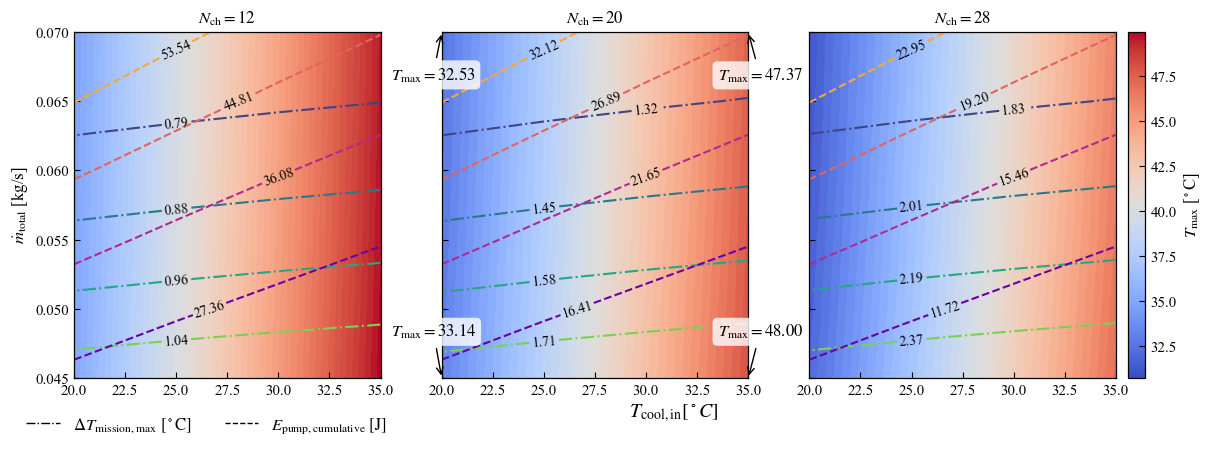

In [6]:
# plot the maximum temperature at varying mass flow rate and inlet temperature for D_h = 8.988 mm

# plot a figure with five sub-figures
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

base_fontsize = 12

# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

fig = plt.figure(figsize=(12, 4))
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("coolwarm", as_cmap=True), norm=plt.Normalize(vmin=T_min, vmax=T_max)))

D_h_selected = 4.3636

thermal_data = data[np.isclose(data['Dh_mm'], D_h_selected)].copy()

thermal_data.head()

key_N_ch = "num_parallel_channels"
key_x = "T_water_in_C"
key_y = "m_dot_total_kg_s"
key_val_T = "Tmax_mission_C"
key_val_dT = "DeltaT_mission_max_C"
key_val_E = "E_pump_cumulative"

N_ch_array = [12, 20, 28]

# locate the global maximum and minimum Tmax_mission_C to set the color ruler
T_max, T_min = thermal_data[key_val_T].max(), thermal_data[key_val_T].min()

# locate the row of the T_max and T_min
T_max_row = thermal_data[thermal_data[key_val_T] == T_max]
T_min_row = thermal_data[thermal_data[key_val_T] == T_min]

mdot_Tmax, Tin_Tmax, N_ch_Tmax = T_max_row[key_y].values[0], T_max_row[key_x].values[0], T_max_row[key_N_ch].values[0]
mdot_Tmin, Tin_Tmin, N_ch_Tmin = T_min_row[key_y].values[0], T_min_row[key_x].values[0], T_min_row[key_N_ch].values[0]

print(f"Tmax: {T_max} at mdot={mdot_Tmax}, Tin={Tin_Tmax}, N_ch={N_ch_Tmax}")
print(f"Tmin: {T_min} at mdot={mdot_Tmin}, Tin={Tin_Tmin}, N_ch={N_ch_Tmin}")

# use one shared y-axis for all sub-figures
# plt.subplots_adjust(hspace=0.3, wspace=0.3)

fig, ax_dict = plt.subplots(1, 3, figsize=(16, 4.5))  # Adjust the number of subplots as needed

i = 0
for N_ch in N_ch_array:
    
    ax = ax_dict[i]
    thermal_data_N_ch = thermal_data[thermal_data[key_N_ch] == N_ch]
    print(f"{len(thermal_data_N_ch)} rows for {key_N_ch} = {N_ch}")

    # select the subfigure for the current N_ch
    # ax = plt.subplot(1, 5, i + 1)
    
    
    # extract the values and transform them into a 2D array     
    x_values = sorted(thermal_data_N_ch[key_x].unique())
    y_values = sorted(thermal_data_N_ch[key_y].unique())
    
    # fill in the Z values
    Z_values_T = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_T).values    
    
    Z_values_dT = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_dT).values
    
    Z_values_E = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_E).values
    
    # local min, max of temperature difference and pump energy    
    # T_max_h, T_max_l = Z_values_T.max(), Z_values_T.min()
    dT_max, dT_min = Z_values_dT.max(), Z_values_dT.min()
    E_max, E_min = Z_values_E.max(), Z_values_E.min()
    
    # extract the T_max and the first column of the Z_values_T
    Z_values_T_left = Z_values_T[:, 0]
    T_max_h_left = Z_values_T_left.max()
    T_max_l_left = Z_values_T_left.min()
    
    Z_values_T_right = Z_values_T[:, -1]
    T_max_h_right = Z_values_T_right.max()
    T_max_l_right = Z_values_T_right.min()
    
    # calculate the space between contours  
    cmap = sns.color_palette("coolwarm", as_cmap=True)    
    
    ax.contourf(
        x_values, 
        y_values, 
        Z_values_T, 
        levels=50, 
        cmap=cmap, 
        vmin=T_min, 
        vmax=T_max)

    cmap_dT = sns.color_palette("viridis", as_cmap=True)
    space_num = 5
    levels_dT = np.arange(dT_min, dT_max + (dT_max - dT_min) / space_num, (dT_max - dT_min) / space_num)
    # display the contour values    
    cs = ax.contour(
        x_values, 
        y_values, 
        Z_values_dT, 
        levels=levels_dT,
        cmap=cmap_dT, 
        vmin=dT_min, 
        vmax=dT_max,
        linestyles='dashdot'
    )
    
    cmap_E = sns.color_palette("plasma", as_cmap=True)
    space_num_E = 5
    levels_E = np.arange(E_min, E_max + (E_max - E_min) / space_num_E, (E_max - E_min) / space_num_E)
    # display the contour values    
    cs_E = ax.contour(
        x_values, 
        y_values, 
        Z_values_E,
        levels=levels_E,
        cmap=cmap_E,
        vmin=E_min, 
        vmax=E_max,
        linestyles='dashed'
    )
    
    # ax.clabel(cs, cs.levels, fmt=label_fmt, fontsize=7)
   
    # if N_ch == 12:
    #     # annotate the global maximum
    #     ax.annotate(
    #         f"Tmax={T_max:.2f}",
    #         xy=(Tin_Tmax, mdot_Tmax),
    #         xytext=(Tin_Tmax - 0.9, mdot_Tmax + 0.005),
    #         arrowprops=dict(facecolor='black', shrink=0.05),
    #         fontsize=8,
    #     )
    
    # if N_ch == 28:
    #     # annotate the global minimum
    #     ax.annotate(
    #         f"Tmin={T_min:.2f}",
    #         xy=(Tin_Tmin, mdot_Tmin),
    #         xytext=(Tin_Tmin + 1, mdot_Tmin - 0.005),
    #         arrowprops=dict(facecolor='black', shrink=0.05),
    #         fontsize=8,
    #     )
    
    if N_ch == 20:
        # annotate the T_max at the four corners of the subfigure for illustration purpose
        ax.annotate(
            fr"$T_\mathrm{{max}}={T_max_l_left:.2f}$",
            xy=(x_values[0], y_values[-1]),
            xytext=(x_values[0]-2.5, y_values[-1]-0.0035),
            arrowprops=dict(arrowstyle='->', facecolor='black'),
            fontsize=base_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white', alpha=0.8),            
        )
        ax.annotate(
            fr"$T_\mathrm{{max}}={T_max_h_left:.2f}$",
            xy=(x_values[0], y_values[0]),
            xytext=(x_values[0]-2.5, y_values[0] + 0.003),
            arrowprops=dict(arrowstyle='->', facecolor='black'),
            fontsize=base_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white', alpha=0.8),            

        )
        ax.annotate(
            fr"$T_\mathrm{{max}}={T_max_l_right:.2f}$",
            xy=(x_values[-1], y_values[-1]),
            xytext=(x_values[-1]-1.5, y_values[-1] - 0.0035),
            arrowprops=dict(arrowstyle='->', facecolor='black'),
            fontsize=base_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white', alpha=0.8),            
        )
        ax.annotate(
            fr"$T_\mathrm{{max}}={T_max_h_right:.2f}$",
            xy=(x_values[-1], y_values[0]),
            xytext=(x_values[-1]-1.5, y_values[0] + 0.003),
            arrowprops=dict(arrowstyle='->', facecolor='black'),
            fontsize=base_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white', alpha=0.8),            
        )
        
        # # plot the curve that connnects all the intersection points
        
        # for mdotc, intersection_T in zip(mdotc_all, intersection_T_all):
        #     print(f'Plotting intersection for Mdot_cin={mdotc} at x={intersection_T}')
        #     # mark the intersection point using a star
        #     ax.plot(intersection_T, mdotc, marker='*', color='red', markersize=10)
        #     # connect these points
        #     if len(intersection_T_all) > 1:
        #         ax.plot(intersection_T_all, mdotc_all, color='red', linestyle='--')
        #     # ax.axvline(intersection_x, color='red', linestyle='--', label=f'Intersection for Mdot_cin={mdotc}')
        #     # ax.annotate(
        #     #     f"Intersection for Mdot_cin={mdotc}",
        #     #     xy=(intersection_x, mdotc),
        #     #     xytext=(intersection_x, 0.005),
        #     #     arrowprops=dict(facecolor='black', shrink=0.05),
        #     #     fontsize=base_fontsize,
        #     # )
            
        # for Tcin, intersection_mdotc in zip(T_cold_in_all, intersection_mdotc_all):
        #     print(f'Plotting intersection for T_cold_in={Tcin} at x={intersection_mdotc}')
        #     ax.plot(Tcin, intersection_mdotc, marker='*', color='blue', markersize=10)
        #     # connect these points
        #     if len(intersection_mdotc_all) > 1:
        #         ax.plot(T_cold_in_all, intersection_mdotc_all, color='blue', linestyle='--')

     
    ax.clabel(cs, inline=True, fontsize=10, fmt=label_fmt, colors='black')
    
    ax.clabel(cs_E, inline=True, fontsize=10, fmt=label_fmt, colors='black')
   
    # hide y-axis for subfigures 2-5
    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
    
    
    # plot the channel number as the subfigure's title
    ax.set_title(rf"$N_\mathrm{{ch}}={N_ch}$")
    
    # if i == 4:        
    #     plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)), cax=ax)
    
    # if i == 4:
    #     cbar = plt.colorbar(
    #         plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)),
    #         ax=ax,            
    #     )
    i += 1
    
# use one shared x-axis label
# fig.supylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
fig.supxlabel(r"$T_\mathrm{cool,in} [^\circ C]$")

# Add a legend for the contour lines
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=1, linestyle='dashdot', label=r'$\Delta T_\mathrm{mission,max}~[\mathrm{^\circ C}]$'),
    Line2D([0], [0], color='black', lw=1, linestyle='dashed', label=r'$E_\mathrm{pump,cumulative}~[\mathrm{J}]$'),
]
# Adjust the legend position and font size as needed

fig.legend(handles=legend_elements, loc='lower right', ncol=2, fontsize=base_fontsize, frameon=False, bbox_to_anchor=(0.33, -0.05))


sm = plt.cm.ScalarMappable(
    cmap=sns.color_palette("coolwarm", as_cmap=True),
    norm=Normalize(vmin=T_min, vmax=T_max),
)
sm.set_array([])

fig.colorbar(sm, ax=fig.axes, label=r"$T_{\max}$ [$^\circ$C]", pad=0.01)

# 第二张图片保存到 EBATS_SCANNED/out/C0003
output_folder = os.path.join(
    root_dir,
    "out",
    CASE_ID
)

os.makedirs(output_folder, exist_ok=True)

output_file = os.path.join(
    output_folder,
    f"{CASE_NAME}_Tmax_dT_E_stage1.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

print("第二张图片已保存到：", output_file)
# plt.close()


In [7]:
# also save the figure to a specified output folder (for paper drafting)

output_folder = r"D:\Workspace\Paper_eBATS\images" # the working directory of the paper draft

import os
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
# overwrite the file
fig.savefig(os.path.join(output_folder, f"{CASE_NAME}_Tmax_dT_E_stage1.png"), dpi=300, bbox_inches='tight')

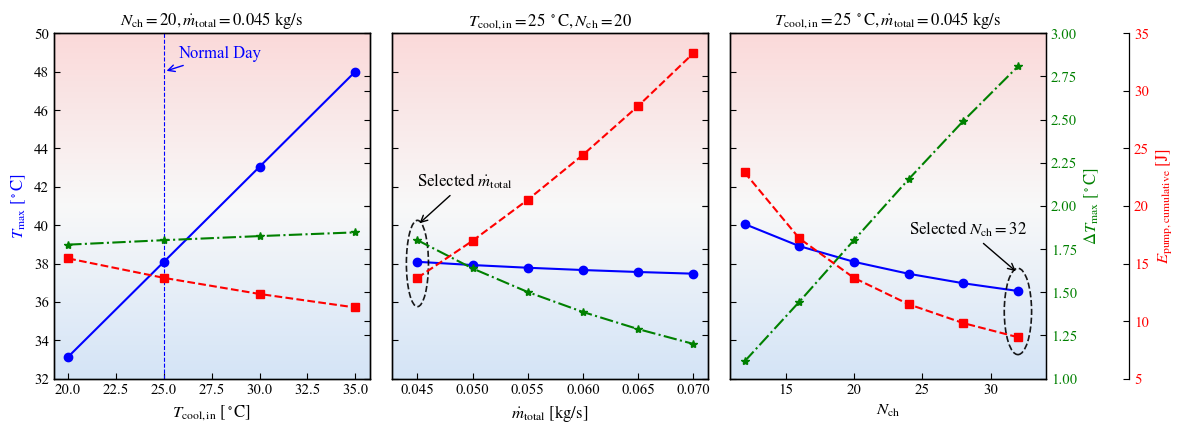

Plot saved to D:\Workspace\Paper_eBATS\images\C0003R02_PARK25_LC_1D_SCAN_details_stage1.pdf


In [8]:
# plot the details for sub figure corresponding to N_ch = 20 as a separate figure
import lib.plot_util as plot_util

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

y1_name = 'Tmax_mission_C'
y2_name = 'DeltaT_mission_max_C'
y3_name = 'E_pump_cumulative'

Tbmax_range = [32, 50]
dTbmax_range = [1, 3]
Epump_range = [5, 35]

# curve artists

curve_artists = {
    y1_name: dict(color='blue', label=r"$T_\mathrm{max}~[^\circ \mathrm{C}]$", ls='-', marker='o'),
    y2_name: dict(color='green', label=r"$\Delta T_\mathrm{max}~[^\circ \mathrm{C}]$", ls='-.',marker='*'),
    y3_name: dict(color='red', label=r"$E_\mathrm{pump,cumulative}~[\mathrm{J}]$", ls='--', marker='s')
}

# plot three curves in a single figure using three y-axis
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

# plot the details for sub figure corresponding to N_ch = 20 as a separate figure

fig, ax_all = plt.subplots(1, 3, figsize=(12, 4.5))


mdot_total_kg_s = 0.045  # fixed mdot_total_kg_s value
N_ch = 20  # fixed number of channels
filtered_data = data[(data['m_dot_total_kg_s'] == mdot_total_kg_s) & (data['num_parallel_channels'] == N_ch)]
x_name = 'T_water_in_C'
x_label = r'$T_\mathrm{cool,in}~[^\circ \mathrm{C}]$'

ax_cur = ax_all[0]

# Plot T_bat_max_C
ax_cur.plot(filtered_data[x_name], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(x_label)
# ax_cur.set_yticklabels([])
ax_cur.set_ylabel(curve_artists[y1_name]['label'], color='blue')
# ax_cur.tick_params(axis='y', labelcolor='blue')
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$N_\mathrm{{ch}} = {N_ch}, \dot{{m}}_\mathrm{{total}} = {mdot_total_kg_s}~\mathrm{{kg/s}}$')

# annotate the performance corresponding to T_cool_in = 25 degrees
T_cool_in = 25
ax_cur.axvline(T_cool_in, color='blue', linestyle='--', linewidth=0.8)
ax_cur.annotate(
    f'Normal Day',
    xy=(T_cool_in, 48),
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='blue'),
    color='blue'
)

# Plot dT_bat_max_C
ax2 = ax_cur.twinx()
ax2.plot(filtered_data[x_name], filtered_data[y2_name], **curve_artists[y2_name])
# ax2.set_ylabel(y2_name, color='green')
# ax2.tick_params(axis='y', labelcolor='green')
ax2.set_yticklabels([])
ax2.set_ylim(dTbmax_range)

# Plot E_pump_cumulative
ax3 = ax_cur.twinx()
# ax3.spines['right'].set_position(('outward', 60))
ax3.plot(filtered_data[x_name], filtered_data[y3_name], **curve_artists[y3_name])
# ax3.set_ylabel(y3_name, color='red')
# ax3.tick_params(axis='y', labelcolor='red')
ax3.set_yticklabels([])
ax3.set_ylim(Epump_range)

x0, x1 = ax_cur.get_xlim()
y0, y1 = ax_cur.get_ylim()
plot_util.draw_plot_bg_gradient(ax_cur, x0, x1, y0, y1)

# plot in the first subplot
# plot the T_bat_max, dT_bat_max, and E_pump_cumulative for a fixed T_cold_in and N_ch = 20
N_ch = 20
T_cold_in = 25  # fixed T cold cin value

filtered_data = data[(data['num_parallel_channels'] == N_ch) & (data['T_water_in_C'] == T_cold_in)]

x_name = 'm_dot_total_kg_s'
x_label = r'$\dot{m}_\mathrm{total}~[\mathrm{kg/s}]$'

ax_cur = ax_all[1]

# Plot Tmax_mission_C
ax_cur.plot(filtered_data[x_name], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(x_label)
# ax_cur.set_ylabel(curve_artists[y1_name]['label'], color='blue')
ax_cur.set_yticklabels([])
ax_cur.tick_params(axis='y', labelcolor='blue')
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$T_\mathrm{{cool,in}} = {T_cold_in}~\mathrm{{^\circ C}}, N_\mathrm{{ch}} = {N_ch}$')

# Draw an ellipse to highlight the target mdot_total_kg_s and T_max condition
mdot_target = 0.045
T_target = 38.0
ax_cur.add_patch(Ellipse(
    (mdot_target, T_target),
    width=0.002,
    height=4.5,
    facecolor='none',
    edgecolor='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.9,
    zorder=5,
))

ax_cur.annotate(
    r'Selected $\dot{m}_\mathrm{total}$',
    xy=(mdot_target, T_target+2.0),
    xytext=(mdot_target, T_target + 4.0),
    textcoords='data',
    fontsize=12,
    color='black',
    # bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.5', alpha=0.8),
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
)

# Plot DeltaT_mission_max_C
ax2 = ax_cur.twinx()
ax2.plot(filtered_data[x_name], filtered_data[y2_name], **curve_artists[y2_name])
# ax2.set_ylabel(y2_name, color='green')
# ax2.tick_params(axis='y', labelcolor='green')
ax2.set_yticklabels([])
ax2.set_ylim(dTbmax_range)

# Plot E_pump_cumulative
ax3 = ax_cur.twinx()
# ax3.spines['right'].set_position(('outward', 60))
ax3.plot(filtered_data[x_name], filtered_data[y3_name], **curve_artists[y3_name])
# ax3.set_ylabel(y3_name, color='red')
# ax3.tick_params(axis='y', labelcolor='red')
# hide the y-axis for the additional y-axes
ax3.set_yticklabels([])
ax3.set_ylim(Epump_range)

x0, x1 = ax_cur.get_xlim()
y0, y1 = ax_cur.get_ylim()
plot_util.draw_plot_bg_gradient(ax_cur, x0, x1, y0, y1)


# plot the details for the third subplot corresponding to fixed mdot_total_kg_s and T_cin 

mdotc = 0.045
T_cin = 25  # fixed T_cold_in value

filtered_data = data[(data['m_dot_total_kg_s'] == mdotc) & (data['T_water_in_C'] == T_cin)]
x_name = 'num_parallel_channels'
x_label = r'$N_\mathrm{ch}$'

ax_cur = ax_all[2]

# Plot T_bat_max_C
ax_cur.plot(filtered_data[x_name], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(x_label)
# ax_cur.set_ylabel(y1_name, color='blue')
ax_cur.set_yticklabels([])
# ax_cur.tick_params(axis='y', labelcolor='blue')
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$T_\mathrm{{cool,in}} = {T_cin}~\mathrm{{^\circ C}}, \dot{{m}}_\mathrm{{total}} = {mdotc}~\mathrm{{kg/s}}$')

N_ch = 32
T_target = 35.5
ax_cur.add_patch(Ellipse(
    (N_ch, T_target),
    width=2,
    height=4.5,
    facecolor='none',
    edgecolor='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.9,
    zorder=5,
))

ax_cur.annotate(
    r'Selected $N_\mathrm{ch}=32$',
    xy=(N_ch, T_target+2.0),
    xytext=(N_ch-8, T_target + 4.0),
    textcoords='data',
    fontsize=12,
    color='black',
    # bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.5', alpha=0.8),
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
)


# Plot dT_bat_max_C
ax2 = ax_cur.twinx()
ax2.plot(filtered_data[x_name], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_ylabel(curve_artists[y2_name]['label'], color=curve_artists[y2_name]['color'])
ax2.tick_params(axis='y', labelcolor=curve_artists[y2_name]['color'])
ax2.set_ylim(dTbmax_range)

# Plot E_pump_cumulative
ax3 = ax_cur.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(filtered_data[x_name], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_ylabel(curve_artists[y3_name]['label'], color=curve_artists[y3_name]['color'])
ax3.tick_params(axis='y', labelcolor=curve_artists[y3_name]['color'])
ax3.set_ylim(Epump_range)

x0, x1 = ax_cur.get_xlim()
y0, y1 = ax_cur.get_ylim()
plot_util.draw_plot_bg_gradient(ax_cur, x0, x1, y0, y1)

# plt.title(f'{y1_name}, {y2_name}, and {y3_name} vs {x_name} at mdot_total_kg_s = {mdot_total_kg_s} and N_ch = {N_ch}')
fig.tight_layout()
plt.show()

# save the plot for presentation

output_folder = os.path.join(root_dir, "out", CASE_ID)
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, f"{CASE_NAME}_details_stage1.png")

fig.savefig(output_file, dpi=300, bbox_inches='tight')

# and a copy into the paper's working folder
output_folder = r"D:\Workspace\Paper_eBATS\images" # the working directory of the paper draft
output_file = os.path.join(output_folder, f"{CASE_NAME}_details_stage1.pdf")

fig.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"Plot saved to {output_file}")

